## v0.6 - MLP Main Target Model
Train an `MLPRegressor` directly on `target_ender_20`, then apply era-wise ranking, optional feature neutralization, evaluation, and export.

In [1]:
import os
import sys
import json
import importlib
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
from dotenv import load_dotenv
from numerapi import NumerAPI

from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")

# Add repo root to path
_REPO_ROOT = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))
if _REPO_ROOT not in sys.path:
    sys.path.insert(0, _REPO_ROOT)

import utils.metrics as metrics_utils
importlib.reload(metrics_utils)
calculate_metrics = metrics_utils.calculate_metrics

from utils.visualization import display_metrics_table
from utils.model_benchmark import record_model_metrics, compare_top_models_with_current

load_dotenv()

True

In [2]:
napi = NumerAPI(
    public_id=os.getenv("NAPI_PUBLIC_ID_UPLOAD"),
    secret_key=os.getenv("NAPI_SECRET_KEY_UPLOAD"),
)

DATA_VERSION = "v5.2"
DATA_DIR = "../../data"
os.makedirs(os.path.join(DATA_DIR, DATA_VERSION), exist_ok=True)

# Download feature metadata
napi.download_dataset(
    f"{DATA_VERSION}/features.json",
    dest_path=os.path.join(DATA_DIR, DATA_VERSION, "features.json"),
)

with open(os.path.join(DATA_DIR, DATA_VERSION, "features.json"), "r") as f:
    feature_metadata = json.load(f)

feature_set = feature_metadata["feature_sets"]["small"]
MAIN_TARGET = "target_ender_20"

2026-03-22 15:57:52,099 INFO numerapi.utils: target file already exists
2026-03-22 15:57:52,115 INFO numerapi.utils: download complete


## 2. Data Loading & Pre-processing

In [3]:
print("Loading data...")

train_columns = ["id", "era"] + feature_set + [MAIN_TARGET]
train = pd.read_parquet(
    os.path.join(DATA_DIR, DATA_VERSION, "train.parquet"),
    columns=train_columns,
)

validation_target_cols = ["target"]
if MAIN_TARGET != "target":
    validation_target_cols.append(MAIN_TARGET)

validation = pd.read_parquet(
    os.path.join(DATA_DIR, DATA_VERSION, "validation.parquet"),
    columns=["id", "era"] + validation_target_cols + feature_set,
)

live = pd.read_parquet(
    os.path.join(DATA_DIR, DATA_VERSION, "live.parquet"),
    columns=["era"] + feature_set,
)

val_benchmarks = pd.read_parquet(
    os.path.join(DATA_DIR, DATA_VERSION, "validation_benchmark_models.parquet"),
)

# Apply 4-era embargo to validation
last_train_era = int(train["era"].unique()[-1])
eras_to_embargo = [str(era).zfill(4) for era in range(last_train_era + 1, last_train_era + 5)]
validation = validation[~validation["era"].isin(eras_to_embargo)].copy()

# Align benchmark rows to the embargoed validation universe
if "id" in val_benchmarks.columns:
    val_benchmarks = val_benchmarks[val_benchmarks["id"].isin(validation["id"])].copy()
if "era" in val_benchmarks.columns:
    val_benchmarks = val_benchmarks[val_benchmarks["era"].isin(validation["era"])].copy()

# Use the same target for training and evaluation unless unavailable
metrics_target_col = MAIN_TARGET if MAIN_TARGET in validation.columns else "target"
if MAIN_TARGET in validation.columns and "target" in validation.columns and MAIN_TARGET != "target":
    target_corr = validation[["target", MAIN_TARGET]].corr().iloc[0, 1]
    identical = validation["target"].equals(validation[MAIN_TARGET])
    print(f"target vs {MAIN_TARGET} corr: {target_corr:.6f} | identical: {identical}")
    if (not identical) and (pd.isna(target_corr) or target_corr < 0.999):
        print(f"Warning: 'target' and '{MAIN_TARGET}' differ; metrics will use '{metrics_target_col}'.")

print(f"Train shape: {train.shape}")
print(f"Validation shape: {validation.shape}")
print(f"Live shape: {live.shape}")
print(f"Validation benchmark shape (aligned): {val_benchmarks.shape}")

Loading data...
target vs target_ender_20 corr: 1.000000 | identical: True
Train shape: (2746268, 44)
Validation shape: (3921307, 45)
Live shape: (7128, 43)
Validation benchmark shape (aligned): (3921307, 9)


## 3. Train MLPRegressor on Main Target (`target_ender_20`)

In [4]:
def rank_by_era(values, eras, index=None):
    series = pd.Series(values, index=index if index is not None else None)
    return series.groupby(eras).rank(pct=True, method="first").values

# Keep only rows with non-null main target for training
train_clean = train[feature_set + ["era", MAIN_TARGET]].dropna().copy()

X_train = train_clean[feature_set].astype(np.float32)
y_train = train_clean[MAIN_TARGET].astype(np.float32)

mlp_model = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        (
            "mlp",
            MLPRegressor(
                hidden_layer_sizes=(256, 128, 64),
                loss="squared_error",
                activation="relu",
                solver="adam",
                alpha=1e-3,
                learning_rate_init=0.001,
                batch_size=1024,
                max_iter=150,
                early_stopping=True,
                validation_fraction=0.05,
                n_iter_no_change=15,
                tol=0.0001,
                random_state=42,
                verbose=True,
            ),
        ),
    ]
)

print("Training MLPRegressor on MAIN_TARGET...")
mlp_model.fit(X_train, y_train)

validation["_raw_prediction"] = mlp_model.predict(validation[feature_set].astype(np.float32))
live["_raw_prediction"] = mlp_model.predict(live[feature_set].astype(np.float32))

print("Training complete.")

Training MLPRegressor on MAIN_TARGET...
Iteration 1, loss = 0.02579070
Validation score: -0.000313
Iteration 2, loss = 0.02515661
Validation score: -0.002016
Iteration 3, loss = 0.02511381
Validation score: 0.001145
Iteration 4, loss = 0.02507172
Validation score: 0.001931
Iteration 5, loss = 0.02503728
Validation score: 0.001543
Iteration 6, loss = 0.02500443
Validation score: 0.002838
Iteration 7, loss = 0.02496387
Validation score: 0.002966
Iteration 8, loss = 0.02491617
Validation score: 0.004119
Iteration 9, loss = 0.02486450
Validation score: 0.002243
Iteration 10, loss = 0.02481050
Validation score: 0.006058
Iteration 11, loss = 0.02476136
Validation score: 0.006861
Iteration 12, loss = 0.02471860
Validation score: 0.008239
Iteration 13, loss = 0.02468132
Validation score: 0.008339
Iteration 14, loss = 0.02464392
Validation score: 0.008440
Iteration 15, loss = 0.02461220
Validation score: 0.007072
Iteration 16, loss = 0.02458705
Validation score: 0.008993
Iteration 17, loss = 0.

## 4. Feature Neutralization

In [8]:
def neutralize(df, columns, pred_col, proportion=0.5, eps=1e-8, rcond=1e-6):
    scores = df[pred_col].values.astype(np.float64, copy=False)
    exposures = df[columns].values.astype(np.float64, copy=False)

    scores = scores - np.nanmean(scores)
    exposures = exposures - np.nanmean(exposures, axis=0, keepdims=True)

    col_std = np.nanstd(exposures, axis=0)
    valid_mask = col_std > eps
    if valid_mask.sum() == 0:
        return pd.Series(scores, index=df.index)

    stable_exposures = exposures[:, valid_mask]
    exposure_pinv = np.linalg.pinv(stable_exposures, rcond=rcond)
    correction = stable_exposures.dot(exposure_pinv.dot(scores))
    neutralized_scores = scores - proportion * correction

    return pd.Series(neutralized_scores, index=df.index)

def neutralize_by_era(df, columns, pred_col, proportion=0.5, eps=1e-8, rcond=1e-6):
    out = pd.Series(index=df.index, dtype=float)
    for _, era_df in df.groupby("era", sort=False):
        out.loc[era_df.index] = neutralize(
            era_df,
            columns,
            pred_col,
            proportion=proportion,
            eps=eps,
            rcond=rcond,
        )
    return out.values

print("Neutralizing validation predictions...")
validation["_neutralized"] = neutralize_by_era(validation, feature_set, "_raw_prediction", proportion=0.5)
print("Neutralizing live predictions...")
live["_neutralized"] = neutralize_by_era(live, feature_set, "_raw_prediction", proportion=0.5)

validation["prediction"] = rank_by_era(validation["_neutralized"].values, validation["era"], validation.index).astype(float)
live["prediction"] = rank_by_era(live["_neutralized"].values, live["era"], live.index).astype(float)

Neutralizing validation predictions...
Neutralizing live predictions...


## 5. Evaluation & Logging

                        KEY PERFORMANCE METRICS vs GOALS                        



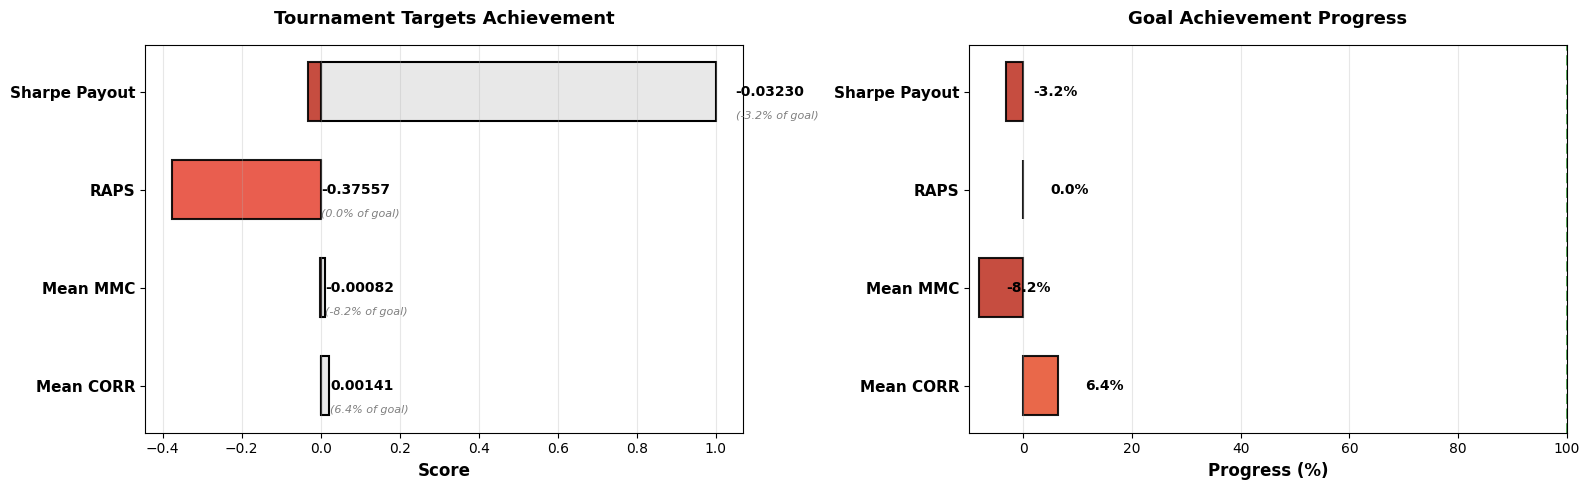

Category,Metric,Value,Goal,Status,Note
Payout,RAPS,-0.3756,+0,🔴 BELOW,Risk-adjusted payout proxy with drawdown and tail-risk penalties
Payout,Mean MMC (BMC Proxy),-0.00082,+0.01,🔴 BELOW,Uniqueness vs benchmark (2× NMR multiplier)
Payout,Mean CORR,+0.00141,+0.022,🔴 BELOW,Official Numerai correlation score (0.5× multiplier)
Risk,Sharpe Ratio,+0.1108,+1,🔴 BELOW,Risk-adjusted return consistency
Risk,Payout Sharpe,-0.0323,+1,🔴 BELOW,Sharpe ratio of payout proxy (0.5×CORR + 2×MMC)
Risk,MMC Volatility,0.01140,—,—,Standard deviation of era-by-era MMC
Risk,Max Drawdown,-0.29527,-0.05,🟡 CLOSE,Worst sustained CORR cumulative loss
Quality,Mean FNC,+0.00083,+0,✅ MET,CORR after removing linear feature exposure
Quality,Win Rate,52.8%,+0.55,🟡 CLOSE,Fraction of eras with positive CORR
Uniqueness,P95 Max Feature Exposure,0.0468,+0.2,✅ MET,95th percentile of strongest single-feature correlation



MODEL LEADERBOARD (Top 3 + Current)


,rank,model_name,run_id,mean_mmc,mean_corr,raps,sharpe_payout,timestamp_utc,is_current
0,1,ridge_meta_prediction_v0.5,2bf11109,0.000954,0.008197,0.0777,0.2056,2026-03-20 19:20:42,False
1,2,lgbm_ensemble_v0.3,52f4b2df,0.000512,0.011083,0.1332,0.2416,2026-03-07 16:38:46,False
2,3,mlp_main_target_v0.6.0,563fb76b,0.000110,0.001997,-0.2105,0.0414,2026-03-21 21:27:41,True


In [9]:
validation_for_metrics = validation.copy()
benchmarks_for_metrics = val_benchmarks.copy()

# Handle validation id whether it's a column, an index, or missing due to stale kernel state.
if "id" in validation_for_metrics.columns:
    validation_for_metrics = validation_for_metrics.set_index("id")
elif validation_for_metrics.index.name == "id":
    pass
else:
    print("'id' missing on validation frame in memory. Reloading validation with ids and aligning predictions...")
    validation_target_cols = ["target"]
    if MAIN_TARGET != "target":
        validation_target_cols.append(MAIN_TARGET)

    validation_with_id = pd.read_parquet(
        os.path.join(DATA_DIR, DATA_VERSION, "validation.parquet"),
        columns=["id", "era"] + validation_target_cols + feature_set,
    )

    # Re-apply embargo exactly as in data-loading cell.
    validation_with_id = validation_with_id[~validation_with_id["era"].isin(eras_to_embargo)].copy()

    if "prediction" not in validation_for_metrics.columns:
        raise ValueError("No 'prediction' column in in-memory validation frame. Re-run training + neutralization cells.")
    if len(validation_with_id) != len(validation_for_metrics):
        raise ValueError(
            "Cannot safely align predictions after reloading validation ids (row counts differ). "
            "Please re-run notebook from Cell 5 onward."
        )

    validation_with_id["prediction"] = validation_for_metrics["prediction"].values
    validation_for_metrics = validation_with_id.set_index("id")

# Handle benchmark id whether it's a column or index.
if "id" in benchmarks_for_metrics.columns:
    benchmarks_for_metrics = benchmarks_for_metrics.set_index("id")
elif benchmarks_for_metrics.index.name == "id":
    pass
else:
    raise ValueError("validation benchmarks are missing 'id'; cannot safely align metrics.")

common_ids = validation_for_metrics.index.intersection(benchmarks_for_metrics.index)
if len(common_ids) == 0:
    raise ValueError("No overlapping ids between validation and benchmark data after filtering.")

validation_for_metrics = validation_for_metrics.loc[common_ids].copy()
benchmarks_for_metrics = benchmarks_for_metrics.loc[common_ids].copy()

benchmark_col = "v52_lgbm_ender20"
if benchmark_col not in benchmarks_for_metrics.columns:
    candidate_cols = [c for c in benchmarks_for_metrics.columns if "ender20" in c.lower()]
    if not candidate_cols:
        raise ValueError("No usable benchmark column found in validation benchmarks.")
    benchmark_col = candidate_cols[0]

if validation_for_metrics["prediction"].notna().sum() == 0:
    raise ValueError("Validation predictions are all NaN.")

metrics, per_era_df = calculate_metrics(
    df_validation=validation_for_metrics,
    benchmarks=benchmarks_for_metrics[[benchmark_col]],
    features=feature_set,
    target_col=metrics_target_col,
    benchmark_col=benchmark_col,
)

display_metrics_table(metrics, extended=True)

model_name = "mlp_main_target_v0.6.0"
notebook_name = Path(globals().get("__vsc_ipynb_file__", "finance_arena_v0.6.0.ipynb")).stem

history_df, current_run = record_model_metrics(
    metrics=metrics,
    model_name=model_name,
    notebook_name=notebook_name,
)

leaderboard_df, is_top = compare_top_models_with_current(
    current_run_id=current_run["run_id"],
    top_n=3,
    show_message=True,
)

print("\nMODEL LEADERBOARD (Top 3 + Current)")
display_df = leaderboard_df.copy()
for col, digits in {"mean_mmc": 6, "mean_corr": 6, "raps": 4, "sharpe_payout": 4}.items():
    if col in display_df.columns:
        display_df[col] = display_df[col].astype(float).round(digits)
display(display_df)

## 6. Export Predict Function

In [11]:
import cloudpickle

def predict(live_features: pd.DataFrame, live_benchmark_models: pd.DataFrame) -> pd.DataFrame:
    """live_benchmark_models is unused in this model version."""

    def _rank_by_era(values, eras, index):
        return pd.Series(values, index=index).groupby(eras).rank(pct=True, method="first").values

    def _neutralize_group(group_df, pred_col, columns, proportion=0.5, eps=1e-8, rcond=1e-6):
        scores = group_df[pred_col].values.astype(np.float64, copy=False)
        exposures = group_df[columns].values.astype(np.float64, copy=False)

        scores = scores - np.nanmean(scores)
        exposures = exposures - np.nanmean(exposures, axis=0, keepdims=True)

        col_std = np.nanstd(exposures, axis=0)
        valid_mask = col_std > eps
        if valid_mask.sum() == 0:
            return pd.Series(scores, index=group_df.index)

        stable_exposures = exposures[:, valid_mask]
        exposure_pinv = np.linalg.pinv(stable_exposures, rcond=rcond)
        correction = stable_exposures.dot(exposure_pinv.dot(scores))
        neutralized_scores = scores - proportion * correction
        return pd.Series(neutralized_scores, index=group_df.index)

    live_df = live_features.copy()
    live_df["_raw_prediction"] = mlp_model.predict(live_df[feature_set].astype(np.float32))

    neutralized = pd.Series(index=live_df.index, dtype=float)
    for _, era_df in live_df.groupby("era", sort=False):
        neutralized.loc[era_df.index] = _neutralize_group(
            era_df,
            "_raw_prediction",
            feature_set,
            proportion=0.5,
        )

    submission = _rank_by_era(neutralized.values, live_df["era"], live_df.index)
    return pd.Series(submission, index=live_df.index).to_frame("prediction")

with open("finance_arena_v0_6_0_mlp_main.pkl", "wb") as f:
    cloudpickle.dump(predict, f)

print("Model exported to finance_arena_v0_6_0_mlp_main.pkl")

Model exported to finance_arena_v0_6_0_mlp_main.pkl
